# LABORATORY EXERCISE 10

# Aim: To deploy a trained artificial intelligence (AI) model as an interactive web application using Streamlit and manage the deployment workflow using Git and GitHub for version control, collaboration, and cloud-based engineering AI solutions.

# Learning Outcomes
# On completing this exercise, the student will be able to:
# 1. Package a trained engineering machine learning or deep learning model into a portable binary format using serialisation libraries.
# 2. Develop an interactive, data-driven web interface using the Streamlit framework to accept engineering inputs and display real-time model predictions.
# 3. Establish a rigorous version control workflow using Git and GitHub to manage source code dependencies, documentation, and operational repositories.
# 4. Deploy an end-to-end artificial intelligence application to a cloud infrastructure platform to deliver accessible, remote engineering decision-making solutions

# Objectives
# 1. Understand the concept of AI model deployment.
# 2. Explain the role of cloud computing in modern AI systems.
# 3. Create an interactive web interface using Streamlit.
# 4. Integrate a trained machine learning or deep learning model into a Streamlit application.
# 5. Accept user inputs through a web interface.
# 6. Perform real-time predictions using a deployed AI model.
# 7. Display prediction results and confidence scores.
# 8. Save and load trained models/files using Joblib or TensorFlow.
# 9. Create a Python virtual environment for deployment.
# 10. Manage source code using Git.
# 11. Create and maintain repositories using GitHub.
# 12. Track project versions using Git commands.
# 13. Push local projects to GitHub repositories.
# 14. Deploy AI applications to cloud platforms.
# 15. Understand best practices for reproducible AI deployment.
# 16. Build complete end-to-end engineering AI solutions.

# STEP 1 IMPORT LIBRARIES

In [ ]:
# APPLE DISEASE CLASSIFICATION USING CNN
# CE1 MINI PROJECT
# Classifying:
# 1. Rotten Apple
# 2. Formalin-mixed Apple

# Import required libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import ( # type: ignore
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

# Lesson 2: Loading and Preparing the Dataset

In [ ]:
# APPLE DISEASE CLASSIFICATION USING CNN
# CE1 MINI PROJECT

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore

# Path to dataset
dataset_path = "dataset/Apple"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,

    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# Training data
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

# Validation data
validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)

print("\nDataset loaded successfully!")
print("Classes:", train_data.class_indices)

Found 1019 images belonging to 2 classes.
Found 254 images belonging to 2 classes.

Dataset loaded successfully!
Classes: {'Formalin-mixed': 0, 'Rotten': 1}


# Step 3: Build the CNN Model

In [ ]:


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential # type: ignore
from keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout # type: ignore

# Dataset path
dataset_path = "dataset/Apple"

# Image preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation"
)


# BUILD CNN MODEL


model = Sequential([

    Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(1, activation="sigmoid")

])

model.summary()

Found 1019 images belonging to 2 classes.
Found 254 images belonging to 2 classes.


c:\Users\BIG PRESH\villain\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# STEP 4: COMPILE THE MODEL

In [ ]:

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


# STEP 5: Add Early Stopping

In [ ]:

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

# Step 6 – Train the Model

In [ ]:

history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 196s 6s/step - accuracy: 0.6114 - loss: 0.6650 - val_accuracy: 0.7283 - val_loss: 0.7201
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 239s 8s/step - accuracy: 0.8508 - loss: 0.3628 - val_accuracy: 0.7520 - val_loss: 0.7511
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 207s 6s/step - accuracy: 0.8891 - loss: 0.2644 - val_accuracy: 0.7126 - val_loss: 0.7415
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 220s 7s/step - accuracy: 0.9019 - loss: 0.2444 - val_accuracy: 0.6339 - val_loss: 0.9179
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 208s 6s/step - accuracy: 0.9215 - loss: 0.2101 - val_accuracy: 0.6732 - val_loss: 1.0913


# comfirming my tensorflow version because i skipped the step

In [7]:
import tensorflow as tf
print(tf.__version__)

2.21.0


 # STEP 7: VISUALIZE TRAINING PERFORMANCE

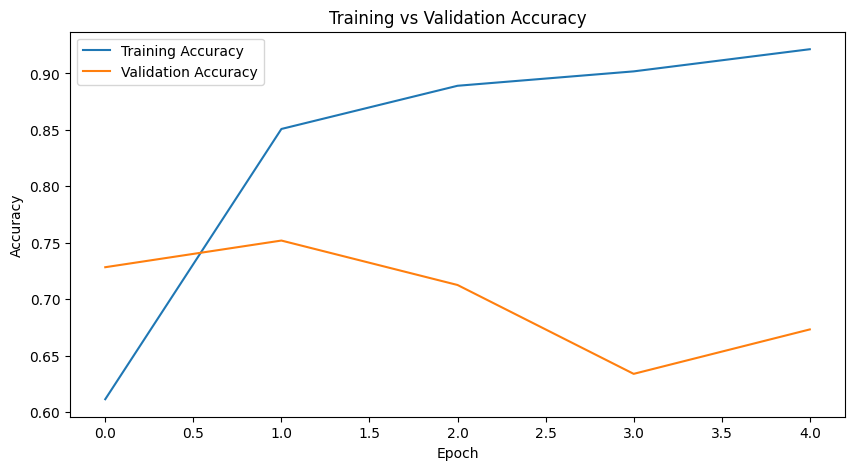

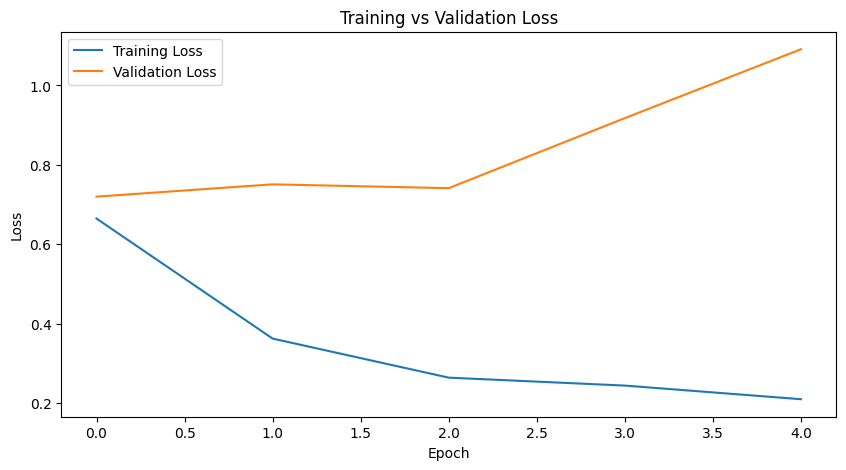

In [10]:


import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# STEP 8: SAVE THE TRAINED MODEL

In [9]:

import os

# Create models folder if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save the trained CNN model
model.save("models/apple_classifier.keras")

print("Model saved successfully!")

Model saved successfully!


In [11]:
print(model.input_shape)

(None, 224, 224, 3)


In [12]:
print(model.output_shape)

(None, 1)
